# 1. Úkoly

## 1.1 Profilování a benchmarking
- Pomocí `line_profiler` zjistěte, které části kódu jsou nejnáročnější (pro `eps = 1e-100`).
- Proveďte benchmarking pomocí `time.time` pro `archimedes_pi` a `newton_pi` pro více hodnot `eps`:
  `1e-1, 1e-2, 1e-3, ..., 1e-100`.
- Výsledky zobrazte v log-log grafu.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from decimal import Decimal as D, getcontext
try:
    from line_profiler import LineProfiler
except ImportError:
    print("Nainstalujte line_profiler: pip install line_profiler")

getcontext().prec = 1000
pi_str = D("3.141592653589793238462643383279\
5028841971693993\
7510582097494459230781640628620899862803482534\
2117067982148086513282306647093844609550582231\
7253594081284811174502841027019385211055596446\
2294895493038196442881097566593344612847564823\
3786783165271201909145648566923460348610454326\
6482133936072602491412737245870066063155881748\
8152092096282925409171536436789259036001133053\
0548820466521384146951941511609433057270365759\
5919530921861173819326117931051185480744623799\
6274956735188575272489122793818301194912983367\
3362440656643086021394946395224737190702179860\
9437027705392171762931767523846748184676694051\
3200056812714526356082778577134275778960917363\
7178721468440901224953430146549585371050792279\
6892589235420199561121290219608640344181598136\
2977477130996051870721134999999837297804995105\
9731732816096318595024459455346908302642522308\
2533446850352619311881710100031378387528865875\
3320838142061717766914730359825349042875546873\
1159562863882353787593751957781857780532171226\
806613001927876611195909216420199")
pi = D(pi_str)

def odmocnina(a, eps):
    x = a
    while abs(x**2 - a) > eps**2:
        x = (a / x + x) / 2
    return x


def archimedes_pi(eps):
    vyska = odmocnina(D(1) - (D(1) / D(2))**2, eps)
    zakladna = D(1)
    i = 1
    while True:
        zakladna = odmocnina((zakladna / 2)**2 + (1 - vyska)**2, eps)
        vyska = odmocnina(1 - (zakladna / 2)**2, eps)
        odhad_pi = 6 * (2**i) * zakladna * (vyska / 2)
        i += 1
        if abs(odhad_pi - pi) < eps:
            break
    return odhad_pi


def newton_pi(eps):
    a = D(0.5) * (D(1) / (2**3))
    pi_suma = D(1 / D(2 * 1 + 1)) * a
    pi_zbytek = ((-1) * odmocnina(D(3), eps)) / D(8) + D(1) / D(2)
    i = D(2)
    while True:
        a *= (D(2 * i - 3) / D(2 * i)) * D(1 / 4)
        pi_suma += (D(1) / D(2 * i + 1)) * a
        odhad_pi = 12 * (pi_zbytek - pi_suma)
        if abs(odhad_pi - pi) < eps:
            break
        i += 1
    return odhad_pi

eps = 1e-100
pi_odhad1 = archimedes_pi(eps)
pi_odhad2 = newton_pi(eps)

print(f"Pi podle Archimedova algoritmu s chybou {abs(pi - pi_odhad1):.4e}")
print(f"Pi podle Newtonova algoritmu s chybou {abs(pi - pi_odhad2):.4e}")

Pi podle Archimedova algoritmu s chybou 6.5629e-101
Pi podle Newtonova algoritmu s chybou 2.6776e-101


In [2]:
eps_profiling = D("1e-100")

profiler = LineProfiler()
profiler.add_function(odmocnina)
profiler.add_function(archimedes_pi)
profiler_wrapper_arch = profiler(archimedes_pi)

print("Profilování archimedes_pi:")
profiler_wrapper_arch(eps_profiling)
profiler.print_stats()

profiler = LineProfiler()
profiler.add_function(odmocnina)
profiler.add_function(newton_pi)
profiler_wrapper_newton = profiler(newton_pi)

print("\nProfilování newton_pi:")
profiler_wrapper_newton(eps_profiling)
profiler.print_stats()

Profilování archimedes_pi:
Timer unit: 1e-07 s

Total time: 2.40321 s
File: C:\Users\Diana\AppData\Local\Temp\ipykernel_28148\1108734938.py
Function: odmocnina at line 36

Line #      Hits         Time  Per Hit   % Time  Line Contents
    36                                           def odmocnina(a, eps):
    37       333       4837.0     14.5      0.0      x = a
    38     15982   11574516.0    724.2     48.2      while abs(x**2 - a) > eps**2:
    39     15649   12441703.0    795.0     51.8          x = (a / x + x) / 2
    40       333      11037.0     33.1      0.0      return x

Total time: 2.46193 s
File: C:\Users\Diana\AppData\Local\Temp\ipykernel_28148\1108734938.py
Function: archimedes_pi at line 43

Line #      Hits         Time  Per Hit   % Time  Line Contents
    43                                           def archimedes_pi(eps):
    44         1      10450.0  10450.0      0.0      vyska = odmocnina(D(1) - (D(1) / D(2))**2, eps)
    45         1         25.0     25.0      0.

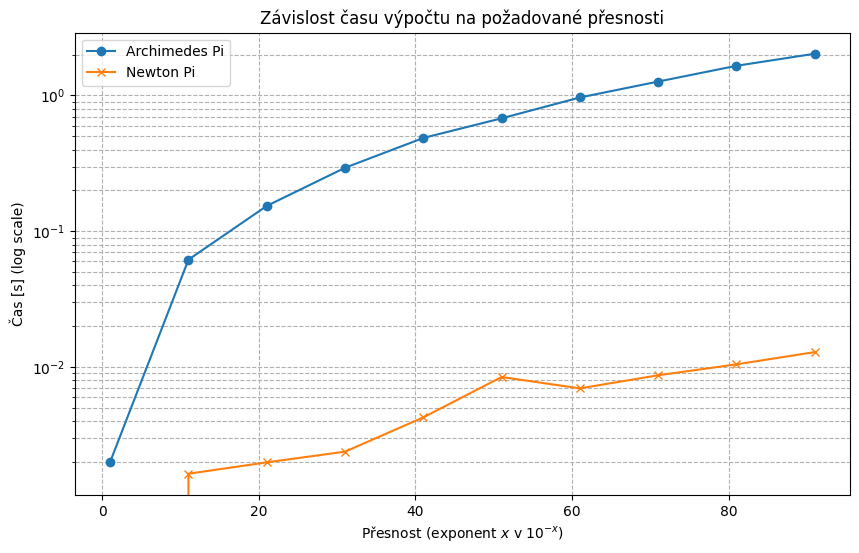

In [3]:
eps_exponents = np.arange(1, 101, 10) 
eps_values = [D(f"1e-{e}") for e in eps_exponents]

times_archimedes = []
times_newton = []

for e in eps_values:
    # Archimedes
    start = time.time()
    archimedes_pi(e)
    times_archimedes.append(time.time() - start)
    
    # Newton
    start = time.time()
    newton_pi(e)
    times_newton.append(time.time() - start)

plt.figure(figsize=(10, 6))
plt.plot(eps_exponents, times_archimedes, label='Archimedes Pi', marker='o')
plt.plot(eps_exponents, times_newton, label='Newton Pi', marker='x')

plt.yscale('log')
plt.xlabel('Přesnost (exponent $x$ v $10^{-x}$)') 
plt.ylabel('Čas [s] (log scale)')
plt.title('Závislost času výpočtu na požadované přesnosti')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 1.2 Prvočísla

Postup zopakujte pro funkce hledající prvočísla menší než `n`:
- profilováním najděte nejnáročnější části,
- benchmarkujte `eratosthenes_sieve` a `primes_test` pro `n = 10, 100, 1000, ..., 1_000_000`,
- výsledky zobrazte v log-log grafu.

In [4]:
import numpy as np

def eratosthenes_sieve(n):
    sieve = np.arange(1, n + 1)
    sieve[0] = 0
    for i in range(2, int(np.sqrt(n)) + 1):
        if sieve[i - 1] != 0:
            sieve[i**2 - 1:n:i] = 0
    return np.where(sieve)[0] + 1

def primes_test(n):
    primes = [2]
    i = 3
    while i < n:
        for p in primes:
            if i % p == 0:
                break
            if p > np.sqrt(i):
                primes.append(i)
                break
        i += 2
    return np.array(primes)

n = 1000
print(eratosthenes_sieve(n))
print(primes_test(n))

[  2   3   5   7  11  13  17  19  23  29  31  37  41  43  47  53  59  61
  67  71  73  79  83  89  97 101 103 107 109 113 127 131 137 139 149 151
 157 163 167 173 179 181 191 193 197 199 211 223 227 229 233 239 241 251
 257 263 269 271 277 281 283 293 307 311 313 317 331 337 347 349 353 359
 367 373 379 383 389 397 401 409 419 421 431 433 439 443 449 457 461 463
 467 479 487 491 499 503 509 521 523 541 547 557 563 569 571 577 587 593
 599 601 607 613 617 619 631 641 643 647 653 659 661 673 677 683 691 701
 709 719 727 733 739 743 751 757 761 769 773 787 797 809 811 821 823 827
 829 839 853 857 859 863 877 881 883 887 907 911 919 929 937 941 947 953
 967 971 977 983 991 997]
[  2   3   5   7  11  13  17  19  23  29  31  37  41  43  47  53  59  61
  67  71  73  79  83  89  97 101 103 107 109 113 127 131 137 139 149 151
 157 163 167 173 179 181 191 193 197 199 211 223 227 229 233 239 241 251
 257 263 269 271 277 281 283 293 307 311 313 317 331 337 347 349 353 359
 367 373 379 383 389 397 

--- Profilování ---
Timer unit: 1e-07 s

Total time: 0.0015935 s
File: C:\Users\Diana\AppData\Local\Temp\ipykernel_28148\3661230898.py
Function: eratosthenes_sieve at line 3

Line #      Hits         Time  Per Hit   % Time  Line Contents
     3                                           def eratosthenes_sieve(n):
     4         1       6682.0   6682.0     41.9      sieve = np.arange(1, n + 1)
     5         1       1089.0   1089.0      6.8      sieve[0] = 0
     6       100       2447.0     24.5     15.4      for i in range(2, int(np.sqrt(n)) + 1):
     7        99       1395.0     14.1      8.8          if sieve[i - 1] != 0:
     8        25       1306.0     52.2      8.2              sieve[i**2 - 1:n:i] = 0
     9         1       3016.0   3016.0     18.9      return np.where(sieve)[0] + 1

Total time: 0.260504 s
File: C:\Users\Diana\AppData\Local\Temp\ipykernel_28148\3661230898.py
Function: primes_test at line 11

Line #      Hits         Time  Per Hit   % Time  Line Contents
    11  

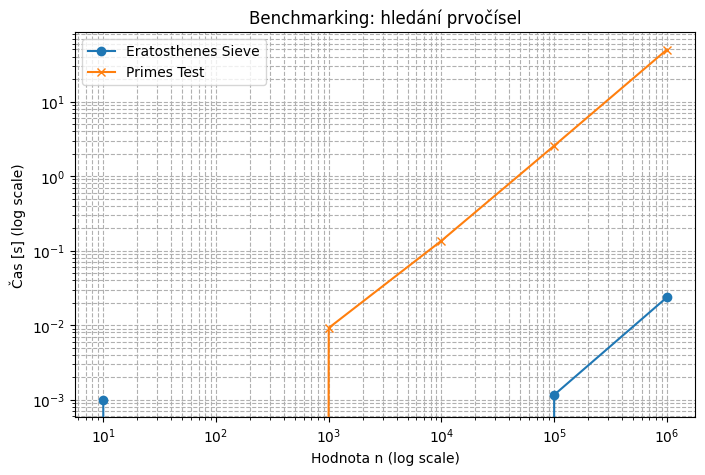

In [5]:
from line_profiler import LineProfiler

profiler_primes = LineProfiler()
profiler_primes.add_function(eratosthenes_sieve)
profiler_primes.add_function(primes_test)

wrapper_sieve = profiler_primes(eratosthenes_sieve)
wrapper_test = profiler_primes(primes_test)

wrapper_sieve(10000)
wrapper_test(10000)

print("--- Profilování ---")
profiler_primes.print_stats()

n_values = [10**i for i in range(1, 7)] 

times_sieve = []
times_test = []

for n_val in n_values:
    t0 = time.time()
    eratosthenes_sieve(n_val)
    times_sieve.append(time.time() - t0)
    
    t0 = time.time()
    primes_test(n_val)
    times_test.append(time.time() - t0)

plt.figure(figsize=(8, 5))
plt.plot(n_values, times_sieve, label='Eratosthenes Sieve', marker='o')
plt.plot(n_values, times_test, label='Primes Test', marker='x')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Hodnota n (log scale)')
plt.ylabel('Čas [s] (log scale)')
plt.title('Benchmarking: hledání prvočísel')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 1.3 Numba

1. Zrychlete obě funkce pro prvočísla pomocí Numby.
2. Porovnejte časy s původními verzemi a proveďte stejný benchmark jako výše.

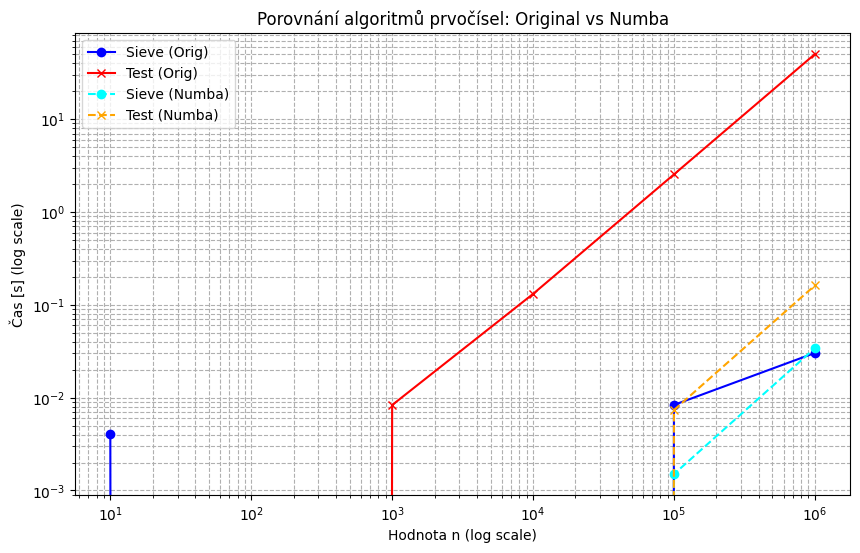

In [6]:
from numba import njit

@njit
def eratosthenes_sieve_numba(n):
    sieve = np.arange(1, n + 1)
    sieve[0] = 0
    for i in range(2, int(np.sqrt(n)) + 1):
        if sieve[i - 1] != 0:
            sieve[i**2 - 1:n:i] = 0
    return np.where(sieve)[0] + 1

@njit
def primes_test_numba(n):
    if n <= 2:
        return np.empty(0, dtype=np.int64)
    
    primes = np.empty(n // 2 + 1, dtype=np.int64)
    primes[0] = 2
    count = 1
    i = 3
    
    while i < n:
        is_prime = True
        limit = np.sqrt(i)
        for j in range(count):
            p = primes[j]
            if i % p == 0:
                is_prime = False
                break
            if p > limit:
                break
        if is_prime:
            primes[count] = i
            count += 1
        i += 2
        
    return primes[:count]

_ = eratosthenes_sieve_numba(10)
_ = primes_test_numba(10)

n_values = [10**i for i in range(1, 7)]

times_sieve = []
times_test = []
times_sieve_numba = []
times_test_numba = []

for n_val in n_values:
    # Eratosthenes original
    t0 = time.time()
    eratosthenes_sieve(n_val) # Předpokládá se, že původní funkce je načtena
    times_sieve.append(time.time() - t0)
    
    # Primes test original
    t0 = time.time()
    primes_test(n_val) # Předpokládá se, že původní funkce je načtena
    times_test.append(time.time() - t0)
    
    # Eratosthenes Numba
    t0 = time.time()
    eratosthenes_sieve_numba(n_val)
    times_sieve_numba.append(time.time() - t0)
    
    # Primes test Numba
    t0 = time.time()
    primes_test_numba(n_val)
    times_test_numba.append(time.time() - t0)

# Log-Log graf
plt.figure(figsize=(10, 6))
plt.plot(n_values, times_sieve, label='Sieve (Orig)', marker='o', color='blue')
plt.plot(n_values, times_test, label='Test (Orig)', marker='x', color='red')
plt.plot(n_values, times_sieve_numba, label='Sieve (Numba)', marker='o', linestyle='--', color='cyan')
plt.plot(n_values, times_test_numba, label='Test (Numba)', marker='x', linestyle='--', color='orange')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Hodnota n (log scale)')
plt.ylabel('Čas [s] (log scale)')
plt.title('Porovnání algoritmů prvočísel: Original vs Numba')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

## 1.4 Numba.stencil

2. Použijte `Numba.stencil` pro aproximaci difuze 2D pole v čase.
- Difuzní kernel má vycházet ze změn podle okolních buněk:
$$u_{i,j} = u_{i,j} + 
\frac{\lambda}{\delta_t}\sum_{k,l \in \{(i,j-1), (i-1,j), \ldots\}} u_{k,l} - u_{i,j}$$

In [7]:
import numpy as np
from numba import stencil, jit
import matplotlib.pyplot as plt


lam = 1e-1
delta_t = 1

# Initialize the grid
N = 100  # Size of the grid (NxN)
grid = np.zeros((N, N))
grid[N // 2, N // 2] = 1000  # Initial concentration in the center

@stencil
def diffuse_step(grid):
    return grid[0, 0] + lam * delta_t * (
        grid[1, 0] + grid[-1, 0] + grid[0, 1] + grid[0, -1] - 4 * grid[0, 0]
    )

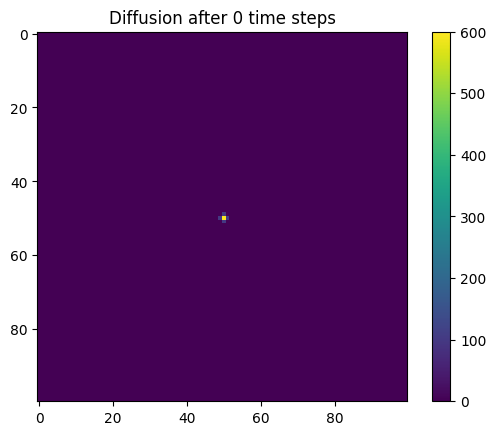

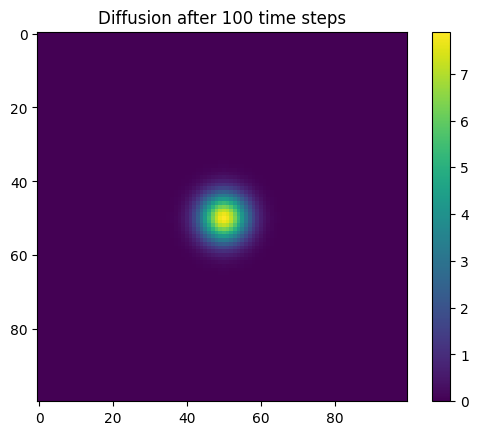

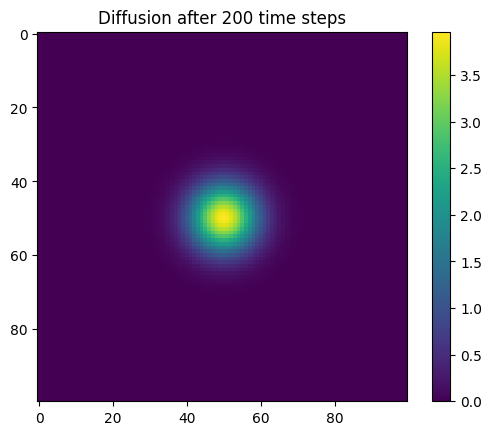

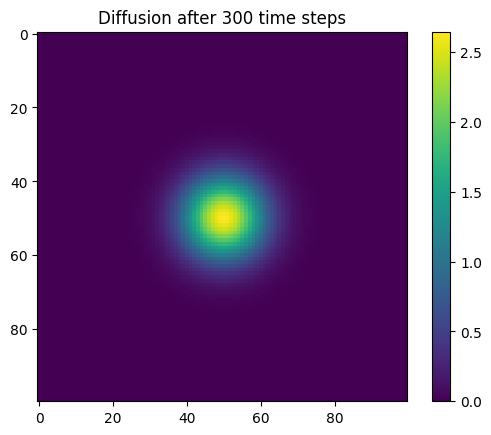

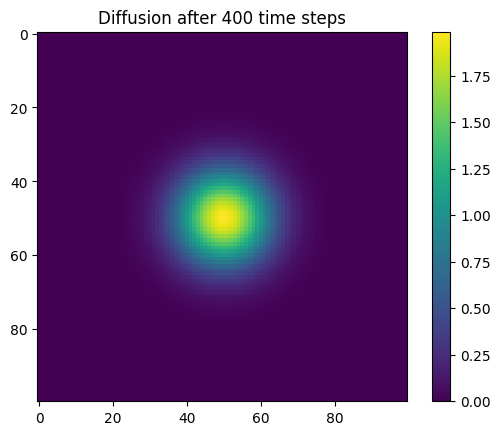

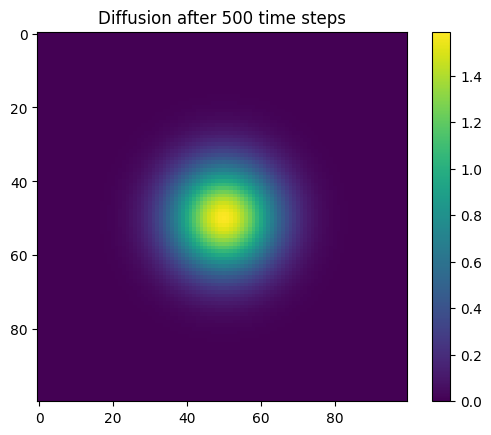

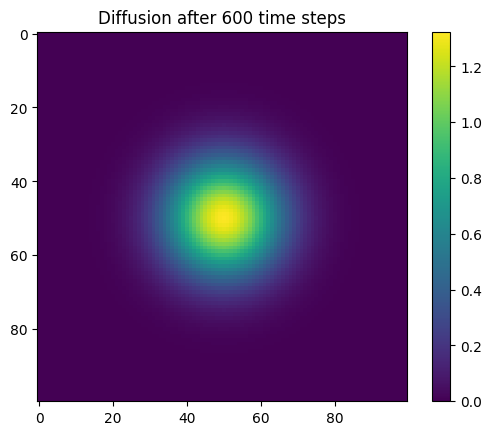

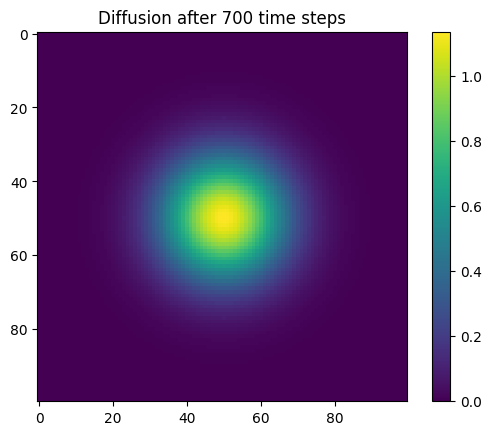

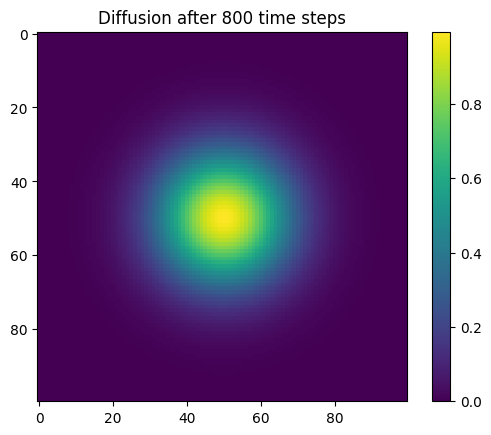

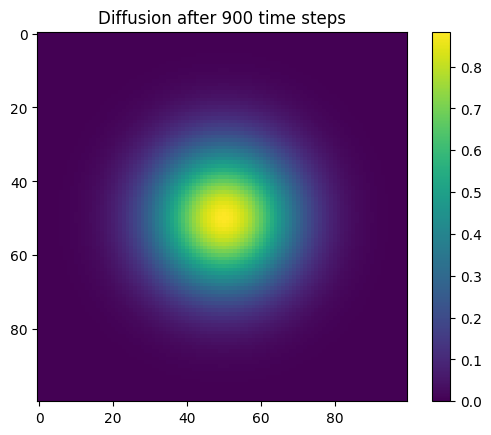

In [8]:
def diffuse(grid, num_steps):
    for time_step in range(num_steps):
        next_grid = diffuse_step(grid)
        if next_grid is None:
            raise NotImplementedError(
                'Funkce diffuse_step není implementovaná (záměrná výuková část úkolu).'
            )

        grid = next_grid
        if time_step % 100 == 0:
            plt.imshow(grid)
            plt.colorbar()
            plt.title(f'Diffusion after {time_step} time steps')
            plt.show()
            plt.close()
    return grid


# Simulate diffusion
num_steps = 1000
result = diffuse(grid, num_steps)